# HNL sensitivity from the forward neutrino flux

Feasibility estimate of a **forward neutrino detector at 5 km** and its reach to a
**heavy neutral lepton (HNL)** $N$ that mixes with the active neutrinos, $|U_{aN}|^2$,
for masses **above the $D$ meson** ($m_N \sim 2$–$6$ GeV). The signal chain, kept
deliberately simple (see `mint/hnl_tools.py`):

1. **Upscattering** $\nu\,\mathcal{N}\to N\,X$ — neutral-current DIS with a mixing
   insertion, $\sigma \simeq |U|^2\,\sigma_{\rm NC}^{\rm SM}(E_\nu)$.
2. **Propagation** — the boosted $N$ ($\gamma_N = E_N/m_N \sim 10^3$) travels through
   the detector.
3. **Decay** $N\to$ visible ($\nu\ell^+\ell^-$, $\ell^\pm+$hadrons, …) inside the volume.

The rate scales as $|U|^2$ (production) $\times$ decay probability, giving the familiar
$|U|^2$ (short-lived) to $|U|^4$ (long-lived) behaviour of the reach. This is a
first pass: the cross section, HNL width, inelasticity and visible branching are all
leading-order/approximate and exposed as parameters.

**Beam simulation (state of the art).** The forward flux uses the packaged 10 TeV IR
lattice with the full 10 km machine circumference: muons circulate for one full
injection period (`cycles="full_injection"`, 0.2 s at 5 Hz), with beam dynamics on,
and the exposure is **1 year of injections**. Detector geometry (flux acceptance and
SM interaction rates) is ray-traced with `mint.detector_tools`.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import vector

import mint
mint.xsecs.use_backend("alfonso")   # tabulated cross sections; the
# normalization used throughout MINT. The "ct18" backend recomputes these
# at LO from CT18NNLO PDFs and runs 10-15% lower in CC; see notebook 0.
from mint import const
from mint import detector_tools as dt
from mint.MuC import MuDecaySimulator

import hnl_tools as hnl  # local module: physics_studies/hnl_tools.py


## 1. Forward neutrino flux at 5 km (from the beam simulation)

In [3]:
nuflavor = "numubar"
ring, sim, injections_per_year = mint.beams.standard_beam(nuflavor, n_evals=5e5)
print(f"Lattice: {ring.s(1)/1e5:.2f} km of the {ring.total_circumference/1e5:.0f} km machine "
      f"({ring.s(1)/ring.total_circumference:.1%} covered)")
print(f"Injections/year: {injections_per_year:.2e}")

# Exposure: 10 years with BOTH beams and identical detectors (mu+ -> downstream,
# mu- -> upstream). The mirror detector sees the CP-conjugate fluxes; treating
# its rates as equal to the ones computed here is exact for the fluxes and
# accurate to the O(10%) nu/nubar NC-DIS difference for the upscattering signal.
# Channels that exist for a single beam orientation only (inverse HNL decay on
# the nuebar_e flux) divide out N_DETECTORS below.
N_YEARS = 10
N_DETECTORS = 2
injections_per_year *= N_YEARS * N_DETECTORS
print(f"mu+ decays in the covered section: {sim.weights.sum() * injections_per_year:.3e} / exposure")

/Users/mhostert/Repos/MINT/mint/MuC.py:491: UserWarning: The lattice covers only 14.6% of the machine (arc length 1.465e+05 cm of total_circumference 1e+06 cm). Muon decays are placed on the covered section only; muon travel times account for propagation through the full machine.
  warnings.warn(


Lattice: 1.46 km of the 10 km machine (14.6% covered)
Injections/year: 5.02e+07
mu+ decays in the covered section: 2.514e+20 / exposure


Detector('benchmark_5km': 75.5 m long, R = 1.28-2.41 m, 38 m of 5 bar Ar, vertex tracker 24x5 cm r<50 cm at 5.00 km)


nu through the 3 m-diameter face at 5 km: 4.433e+19 / exposure  (82336 MC events)


SM numubar interactions in detector (gas+targets): 4.431e+11 / exposure


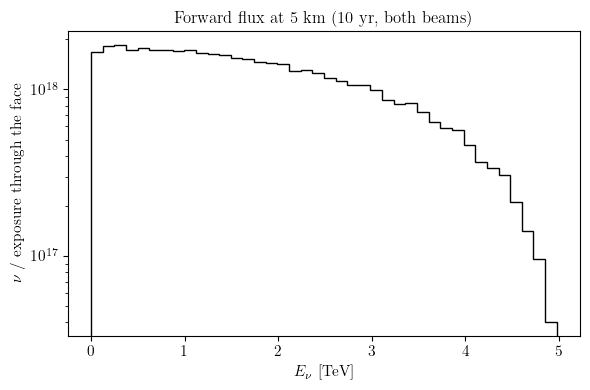

In [4]:
det = mint.detectors.load("benchmark_5km")
DIST, DET_R, GAP = det.dist, det.radius, det.gap
DET_L = det.fiducial_length          # active gas = the decay volume
gas, TARGET_MAT = det.gas, det.vertex_mat
N_TARGETS, TARGET_THICK = det.n_plates, det.foil_thick
target_positions = np.linspace(det.Z_VTX0, det.Z_VTX1, det.n_plates,
                               endpoint=False)
targets = [(det.Z_VTX0, det.Z_VTX1 - det.Z_VTX0, det.vertex_mat)]
print(det)

# ray-trace the nu flux through the gas cylinder (front face at DIST)
E_nu, w_nu, chord_nu = det.flux_with_chords(sim, exposure=injections_per_year)
print(f"nu through the {2*DET_R/100:.0f} m-diameter face at 5 km: {w_nu.sum():.3e} / exposure  "
      f"({E_nu.size} MC events)")

# SM interaction background scale: gas + the 3 W target slabs
det_bkg = det.detector()          # every volume, for the SM rate
sm = det_bkg.generate_interactions(sim, exposure=injections_per_year)
print(f"SM {nuflavor} interactions in detector (gas+targets): {sm.attrs['total_interactions']:.3e} / exposure")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(E_nu / 1e3, bins=40, weights=w_nu, histtype="step", color="black", lw=1.5)
ax.set_xlabel(r"$E_\nu$ [TeV]"); ax.set_ylabel(r"$\nu$ / exposure through the face")
ax.set_yscale("log"); ax.set_title("Forward flux at 5 km (10 yr, both beams)")
plt.tight_layout()

## 2. HNL ingredients: upscattering cross section, decay width, decay length

The **total decay width is now channel-resolved** (`hnl_widths`): leptonic modes
($3\nu$, $\nu\ell^+\ell^-$, $\ell\ell'\nu$), exclusive meson modes below ~1 GeV
(N $\to \ell\pi,\ell K,\ell\rho,\nu\pi^0,\nu\eta,\nu\rho^0,\dots$; decay constants and
couplings from Coloma et al. arXiv:2007.03701), and inclusive quark-level modes above,
matched by quark-hadron duality. This replaces the old $\Gamma\propto n_{\rm eff}\,G_F^2 m_N^5$
guess (which was worst exactly at low mass, where channels switch on one at a time).

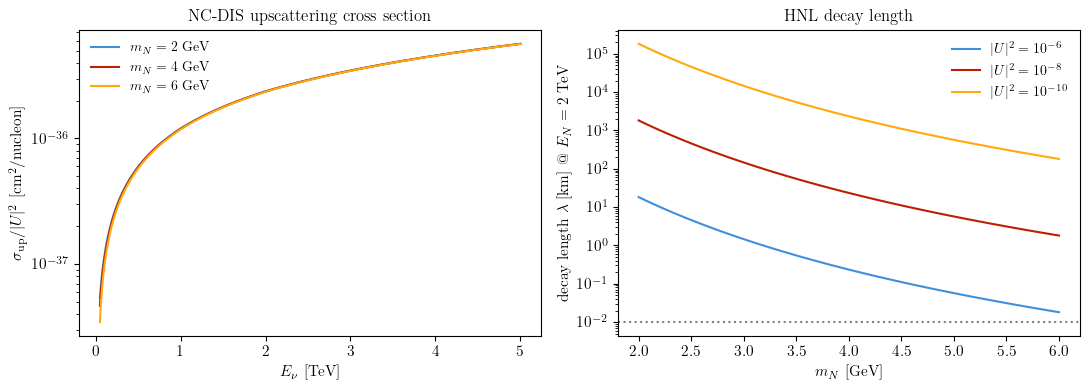

In [5]:
Egrid = np.geomspace(50, 5e3, 200)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# upscattering cross section (per nucleon), shown at |U|^2 = 1 to factor it out
for mN in [2.0, 4.0, 6.0]:
    ax[0].plot(Egrid/1e3, hnl.mixing_upscattering_xsec(Egrid, mN, 1.0, nuflavor),
               label=fr"$m_N={mN:.0f}$ GeV")
ax[0].set_xlabel(r"$E_\nu$ [TeV]")
ax[0].set_ylabel(r"$\sigma_{\rm up}/|U|^2$  [cm$^2$/nucleon]")
ax[0].set_yscale("log"); ax[0].legend(frameon=False)
ax[0].set_title("NC-DIS upscattering cross section")

# HNL lab decay length vs mass, at E_N = 2 TeV
E_N = 2000.0
mgrid = np.linspace(2.0, 6.0, 100)
for U2 in [1e-6, 1e-8, 1e-10]:
    lam = hnl.decay_length(E_N, mgrid, hnl.mixing_total_width(mgrid, U2))
    ax[1].plot(mgrid, lam/1e5, label=fr"$|U|^2=10^{{{int(np.log10(U2))}}}$")
ax[1].axhline(0.01, ls=":", color="gray")  # 10 m detector in km
ax[1].set_xlabel(r"$m_N$ [GeV]"); ax[1].set_ylabel(r"decay length $\lambda$ [km] @ $E_N=2$ TeV")
ax[1].set_yscale("log"); ax[1].legend(frameon=False)
ax[1].set_title("HNL decay length")
plt.tight_layout()


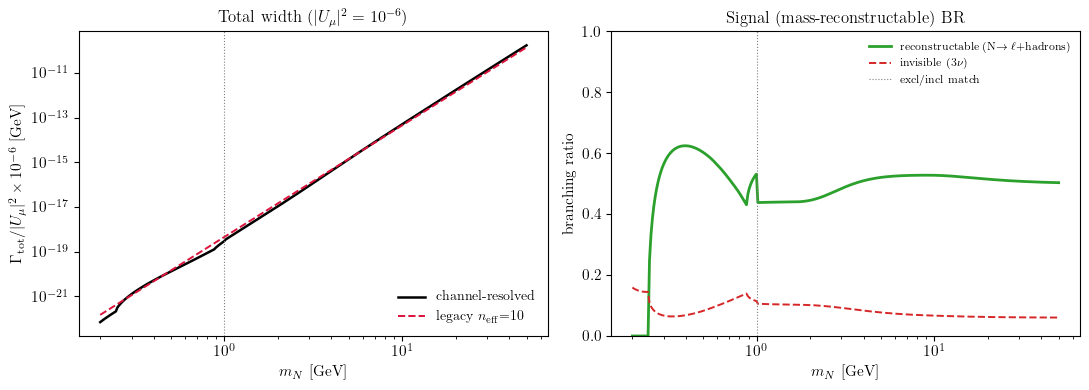

In [6]:
import hnl_widths

# Channel-resolved total width and its leptonic/hadronic split vs mass,
# compared to the legacy n_eff = 10 estimate.
mN = np.geomspace(0.2, 50, 300)
Gam = hnl_widths.hnl_total_width(mN, 1e-6, flavor="mu")
Gam_crude = hnl.mixing_total_width_crude(mN, 1e-6, n_eff=10.0)
brk = ("reconstructable", "invisible")
br = np.array([[hnl_widths.branching_ratios(m, "mu")[k] for m in mN] for k in brk])

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(mN, Gam, color="black", lw=1.8, label="channel-resolved")
ax[0].plot(mN, Gam_crude, color="crimson", ls="--", lw=1.4, label=r"legacy $n_{\rm eff}{=}10$")
ax[0].axvline(1.0, color="gray", ls=":", lw=0.8)
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel(r"$m_N$ [GeV]"); ax[0].set_ylabel(r"$\Gamma_{\rm tot}/|U_\mu|^2\times10^{-6}$ [GeV]")
ax[0].legend(frameon=False); ax[0].set_title("Total width ($|U_\mu|^2=10^{-6}$)")

ax[1].plot(mN, br[0], color="tab:green", lw=2,
           label="reconstructable (N$\\to\\ell$+hadrons)")
ax[1].plot(mN, br[1], color="tab:red", lw=1.4, ls="--", label="invisible (3$\\nu$)")
ax[1].axvline(1.0, color="gray", ls=":", lw=0.8, label="excl/incl match")
ax[1].set_xscale("log"); ax[1].set_xlabel(r"$m_N$ [GeV]"); ax[1].set_ylabel("branching ratio")
ax[1].set_ylim(0, 1); ax[1].legend(frameon=False, loc="upper right", fontsize=8)
ax[1].set_title("Signal (mass-reconstructable) BR")
plt.tight_layout()

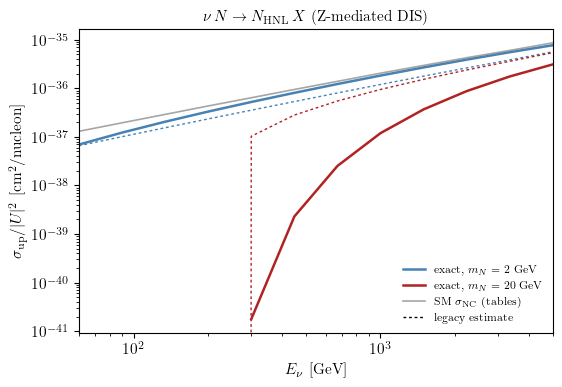

In [7]:
# Validation: exact Z-mediated DIS upscattering (DarkNews + CT18NNLO) vs the
# legacy |U|^2 sigma_NC^SM x linear-threshold estimate, per nucleon (isoscalar O16).
from mint import plot_tools as pt
from mint import xsecs

E_val = np.geomspace(60, 5e3, 12)
fig, ax = pt.std_fig(figsize=(6, 4))
for m, c in [(2.0, "steelblue"), (20.0, "firebrick")]:
    exact = hnl.darknews_nc_dis_xsec(E_val, m, target="O16", ref_U2=1.0) / 16.0
    legacy = hnl.mixing_upscattering_xsec(E_val, m, 1.0, "numubar")
    good = exact > 0
    ax.plot(E_val[good], exact[good], color=c, lw=1.8, label=rf"exact, $m_N = {m:g}$ GeV")
    ax.plot(E_val, legacy, color=c, lw=1.0, ls=(0, (2, 2)))
ax.plot(E_val, xsecs.sigma_NC_nu(E_val), color="gray", lw=1.2, ls="-",
        alpha=0.7, label=r"SM $\sigma_{\rm NC}$ (tables)")
ax.plot([], [], color="black", lw=1.0, ls=(0, (2, 2)), label="legacy estimate")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(E_val[0], E_val[-1])
ax.set_xlabel(r"$E_\nu$ [GeV]")
ax.set_ylabel(r"$\sigma_{\rm up}/|U|^2$ [cm$^2$/nucleon]")
ax.set_title(r"$\nu\, N \to N_{\rm HNL}\, X$ (Z-mediated DIS)", fontsize=11)
ax.legend(frameon=False, fontsize=8, loc="lower right")
fig.savefig("plots/hnl_mixing_xsec_validation.pdf", bbox_inches="tight", dpi=300)

## 3. Signal scan over $(m_N,\ |U|^2)$

A **3 cm minimum displacement** between the upscattering (production) vertex and the
decay vertex is required, to reject prompt SM backgrounds. This also removes short-lived
HNLs ($\lambda \ll 3$ cm), so the reach band **closes at strong coupling** (an upper
edge appears) instead of extending indefinitely.

The signal is weighted by the **mass-reconstructable branching ratio** (channel-resolved `hnl_widths.visible_br`): only decays with **no final-state neutrino** — the charged-current modes $N\to\ell^-+\,$hadrons ($\ell\pi,\ell K,\ell\rho,\ell qq'$) — allow full reconstruction of $m_N$ from the visible products. This replaces the old flat 50% visible fraction.

**Production inputs (DarkNews everywhere).** The upscattering cross section is now the
exact Z-mediated DIS from DarkNews (`hnl_tools.DarkNewsMixingPortal`): PDF-convolved
(CT18NNLO, $Q^2 > 2$ GeV$^2$), with the proper massive-$N$ kinematic suppression and
the finite-$Z$ propagator, tabulated per (mass, material) — W184 slabs, Ar40 gas, Na23
for standard rock — and disk-cached. This replaces the legacy
$|U|^2 \sigma_{\rm NC}^{\rm SM}(E_\nu) \times$ linear-threshold estimate, which the
validation (`validate_dipole_xsecs.py`, part E) shows overestimates production by
$\times 2.4$ at $m_N = 10$ GeV up to $\times 13$ at 20 GeV; in the light-$N$ limit the
exact result reproduces the SM $\sigma_{\rm NC}$ tables to $\sim 4\%$.

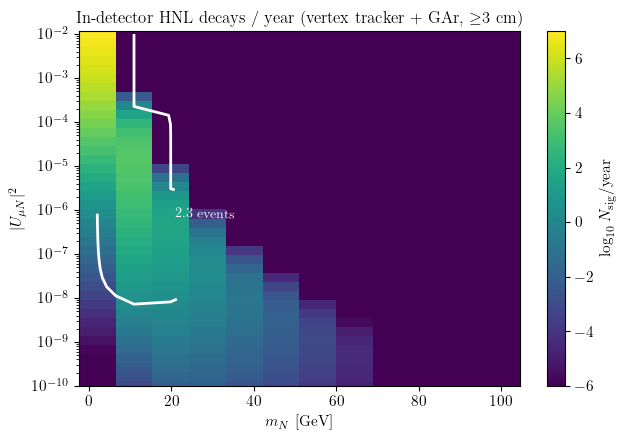

In [8]:
MIN_DISP = 3.0   # cm: minimum production->decay displacement (into the gas)
Ec_val, Wc_val = dt.bin_flux(E_nu, w_nu, n_bins=60)   # quadrature grid

m_N_grid = np.linspace(2.0, 100.0, 12)    # small validation grid
U2_grid = np.geomspace(1e-10, 1e-2, 40)   # small validation grid

# In-detector reach: production in the vertex tracker and gas, decay in the gas.
N_sig = np.zeros((m_N_grid.size, U2_grid.size))
for i, m in enumerate(m_N_grid):
    p = hnl.DarkNewsMixingPortal(m, materials=[gas, TARGET_MAT], nuflavor=nuflavor)
    for j, u in enumerate(U2_grid):
        N_sig[i, j] = hnl.signal_events_detector(
                Ec_val, Wc_val, p, u, det, min_displacement_cm=MIN_DISP)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
pc = ax.pcolormesh(m_N_grid, U2_grid, np.log10(np.clip(N_sig.T, 1e-6, None)),
                   shading="auto", cmap="viridis")
cs = ax.contour(m_N_grid, U2_grid, N_sig.T, levels=[2.3], colors="white", linewidths=2)
ax.clabel(cs, fmt="2.3 events")
ax.set_yscale("log"); ax.set_xlabel(r"$m_N$ [GeV]"); ax.set_ylabel(r"$|U_{\mu N}|^2$")
fig.colorbar(pc, label=r"$\log_{10} N_{\rm sig}$/year")
ax.set_title(r"In-detector HNL decays / year (vertex tracker + GAr, $\geq$3 cm)")
plt.tight_layout()

## 4. Sensitivity reach (90% CL, background-free)

best reach: |U|^2 ~ 1.13e-08 at m_N = 10.91 GeV
masses with a closed band (upper edge): 2 / 3


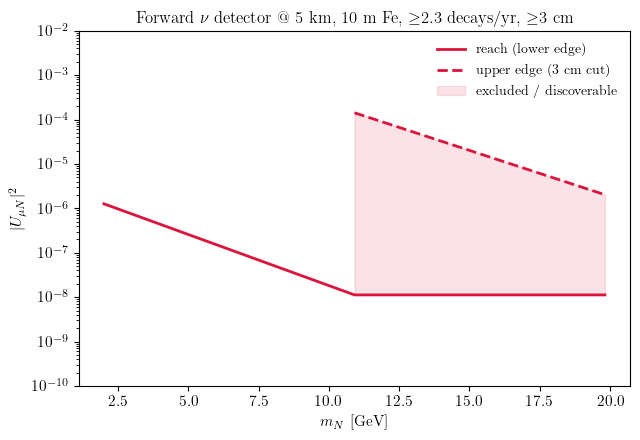

In [9]:
lower, upper = hnl.exclusion_band(m_N_grid, U2_grid, N_sig, n_events=2.3)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(m_N_grid, lower, color="crimson", lw=2, label="reach (lower edge)")
ax.plot(m_N_grid, upper, color="crimson", lw=2, ls="--", label="upper edge (3 cm cut)")
ax.fill_between(m_N_grid, lower, upper, color="crimson", alpha=0.12,
                label="excluded / discoverable")
ax.set_yscale("log"); ax.set_ylim(1e-10, 1e-2)
ax.set_xlabel(r"$m_N$ [GeV]"); ax.set_ylabel(r"$|U_{\mu N}|^2$")
ax.set_title(r"Forward $\nu$ detector @ 5 km, 10 m Fe, $\geq$2.3 decays/yr, $\geq$3 cm")
ax.legend(frameon=False)
plt.tight_layout()

i_best = np.nanargmin(lower)
print(f"best reach: |U|^2 ~ {np.nanmin(lower):.2e} at m_N = {m_N_grid[i_best]:.2f} GeV")
print(f"masses with a closed band (upper edge): {np.isfinite(upper).sum()} / {np.isfinite(lower).sum()}")

## 5. Including the rock: upscattering upstream of the detector

Unlike the dipole portal (fast EM decay, high-$Z$ coherent production), the **minimal
HNL is the case where the rock pays off**: the decay is weak, $\Gamma\propto|U|^2
G_F^2 m_N^5$, so a GeV-scale $N$ has $\gamma c\tau\sim$ km at the reach coupling, and the
production is per-nucleon (Z-blind), so the huge nucleon column of the rock competes.
HNLs upscattered in the rock between the straight section and the detector then survive
to decay in the fiducial block. The reach improves by $\sim\!10\times$, and there is an
**optimal distance** where the growing rock production balances the falling flux
acceptance.

**Cuts applied here.** In-detector production requires a **3 cm displacement** between the
upscattering and decay vertices (closes the band at strong coupling). Rock-produced HNLs
have no visible production vertex, so instead the **visible decay $p_T > 1$ GeV** is
required — this rejects the soft, forward SM background and removes $m_N < 2\,p_T^{\rm min}$.

In [10]:
# Overlay of existing HNL limits (optional): requires the HNLimits package,
# https://github.com/mhostert/HNLimits. Without it, the reach is plotted on bare axes.
try:
    from HNLimits import plot_tools, hnl_tools
    case_muon = hnl_tools.Limits(flavor='mu', invisible=False, nature='majorana')
    HAS_HNLIMITS = True
except ImportError:
    HAS_HNLIMITS = False
    print("HNLimits not installed -- plotting the reach without the existing-limits overlay.")

In [11]:
kwargs = {
    'xrange': (1e-1, 100),
    'yrange': (1e-10, 1e-3),
        #
        'skip_ids': [
            'cms_2018_dilepton',
            'cms_2016',
            'atlas_2019_prompt', # replaced by atlas_2025_prompt
            'kek',
        ],
        #
        'new_color': {
            'psi': '#A0C3D2', #7ECA9C 9D0191 3A0088 7149C6 F67FF5 9E4784 ECA0B6 39B5E0
            'pienu_le': '#F29191',
            'pienu_he': '#F29191',  #B643CD E36387
            'microboone_higgs': '#444444', #40394A BFB051 
            't2k_lowmass': 'peachpuff', #9B45E4 007965 354259 060047
            't2k': '#FA697C', # 
            'kek': 'orchid', #F3CCFF FFA3FD
            'na62': '#8DCBE6', 
            'nutev': '#41AEA9', #3797A4 
            'bebc': '#8F4068', #F4EEED', 
            'na3': 'gold', 
            'delphi_short': '#93329E',  
            'atlas_2025_prompt': 'gold', 
            'atlas_2022': '#A799B7', #FE6244 
            'atlas_top_2024': 'yellow', #FE6244 
            'cms_2024': '#FE6244', 
            'cms_2022': '#FF9668', 
            'cms_2018_trilepton': '#7579E7',
            'pmns_unitarity': '#52057B', #FBCB0A FFD615 FFD581 213E3B
            'cosmo': 'grey',
            'microboone_2023': 'indigo',
            'e949': 'grey',
            'lsnd_ema': '#43919B',
            'charmii': 'royalblue',
        },
        #
        # 'new_dash': {
            # 'cosmo': (1,(4,2))
        # },
        #
        'new_labelpos': {
            'psi': (10e-3,3.1e-6),
            'pienu_le': (21e-3,10e-6),
            'pienu_he': (20e-3,7.2e-7),
            't2k_lowmass': (34e-3,2.8e-6),
            'microboone_higgs': (1.7e-2,1.9e-4),
            'na3': (1.3,7e-6),
            'kek': (2.2e-1,3.7e-7),
            'nutev': (0.8,3e-8),
            'bebc': (4.9e-1,3e-7),
            't2k': (4e-1, 9e-10),
            'na62': (4.1e-1, 7e-9),
            'delphi_short': (7,5.8e-6),
            'cms_2022': (16,4e-7*0),
            'cms_2024_1': (2.05,2.8e-6*0),
            'cms_2024_2': (4e1,1.2e-6*0),
            'cms_2024_3': (2.4,1.4e-5*0),
            'atlas_2025_prompt': (2.3e1,2.3e-6*0),
            'atlas_2022': (8,1.2e-7*0),
            'atlas_top_2024': (15,0.35e-4*0),
            'atlas_displaced_2025': (2e2,8e-3*0),
            'cms_2018_trilepton': (4e1,8e-6*0),
            'pmns_unitarity': (1e2,8e-5),
            'cosmo': (1.4e-3,2e-10),
            'microboone_2023': (0.82e-1,5e-8),
            'e949': (1e-1,3e-9),
            'charmii': (0.25,3e-4),
        },
        'new_rotation': {
            'pienu_le': 90,
            't2k_lowmass': -40,
            'microboone_higgs': -45,
            'bebc': -42,
            'kek': 0,
            'charmii': -36
        },
        # 'colormap': 'hsv',
        # 'colormap_range': (0.1,1),
        # 'force_label_color': 'black',
        # 'alpha' : 1
        'color_only': ['charm','borexino','t2k','bebc_barouki','lsnd_ema','nutev','microboone_higgs','t2k_lowmass','charmii','microboone_2023'],
        'figsize': (5,4),

    }




# FASER2_color='black'
# x,y = np.genfromtxt('src/HNLimits/include/data/FASER_2018/converted_HNLmu_contour_FASER2.txt', unpack=True)
# ax.fill(x,y, facecolor='None', edgecolor=FASER2_color, ls=(1,(5,1)), lw=1.2, label='FASER2', zorder=10)

# ax.legend(loc='lower left', fontsize=9, frameon=False, ncol=1)

In [12]:
Lss_half = det.rock_start        # rock begins at 250 m
L_fid = det.fiducial_length      # 38 m of active gas = the decay volume
rock = dt.standard_rock

def flux_at(D):
    """Energies, annual weights and chords of the flux through the signal
    volume (vertex tracker + gas) with the front face at z = D [cm]."""
    return det.flux_with_chords(sim, exposure=injections_per_year, dist=D)

m_N_grid = np.geomspace(0.3, 100.0, 200)
U2_grid = np.geomspace(1e-11, 1e-3, 200)
distances = [5e5]            # 1, 5, 20 km
colors = ["steelblue", "firebrick"]

# ---- inverse-HNL-decay (IHD) production on the nuebar_e flux ----
# nuebar_e e- -> mu- Nbar (|U_mu4|^2): the nuebar_e flux illuminates the
# UPSTREAM detector only (mu- beam), so IHD weights divide out N_DETECTORS.
# The nuebar_e spectrum is the exact CP mirror of the nu_e one.
sim_e = sim.reweighted_copy(nuflavor="nue")
sim_e.place_muons_on_lattice(lattice=ring, direction="clockwise")

def flux_at_e(D):
    return det.flux_with_chords(sim_e, exposure=injections_per_year, dist=D)

def bin_flux_ihd(E, w, n=60):
    edges = np.geomspace(max(20.0, E.min() * 0.999), E.max() * 1.001, n + 1)
    W, _ = np.histogram(E, bins=edges, weights=w)
    Es, _ = np.histogram(E, bins=edges, weights=w * E)
    m = W > 0
    return Es[m] / W[m], W[m]

E_eb_raw, w_eb_raw, _ = flux_at_e(5e5)
Ec_ihd, Wc_ihd = bin_flux_ihd(E_eb_raw, w_eb_raw / N_DETECTORS)
geom_ihd = hnl.BeamDumpGeometry(Lss_half, 5e5, L_fid, rock=rock,
                                fiducial_produces=False, gap_cm=GAP)

import hnl_widths
N_ihd_mu = np.zeros((m_N_grid.size, U2_grid.size))
for i, m in enumerate(m_N_grid):
    if m > 2.2:
        continue
    vis_mu = hnl_widths.visible_br(m, flavor="mu")   # same criterion as the panel
    for j, u in enumerate(U2_grid):
        N_ihd_mu[i, j] = hnl.signal_events_ihd(
            Ec_ihd, Wc_ihd, m, u, geom_ihd, DET_L, gas, targets,
            flavor="mu", min_displacement_cm=MIN_DISP, br_vis=vis_mu)
print("IHD |U_mu4|^2 grid ready; max events:", N_ihd_mu.max())

/Users/mhostert/Repos/MINT/mint/MuC.py:491: UserWarning: The lattice covers only 14.6% of the machine (arc length 1.465e+05 cm of total_circumference 1e+06 cm). Muon decays are placed on the covered section only; muon travel times account for propagation through the full machine.
  warnings.warn(


IHD |U_mu4|^2 grid ready; max events: 48547.20305055665


In [13]:
# cspell:ignore nuflavor beamdump

MIN_DISP = 5.0
PT_MIN = 0.0  # GeV: pT cut for rock-produced HNLs (no visible production vertex)

scan_results = {}

for D, c in zip(distances, colors):
    E, w, ch = flux_at(D)
    # Bin the flux before scanning: the signal is an integral over the
    # spectrum, so 60 quadrature points reproduce the 33k-event sum to 4
    # decimals while making the (mass, coupling) grid ~60x cheaper.
    E, w = dt.bin_flux(E, w, n_bins=60)
    geom = hnl.BeamDumpGeometry(Lss_half, D, L_fid, rock=rock, fiducial_produces=False, gap_cm=GAP)

    N_only = np.zeros((m_N_grid.size, U2_grid.size))
    N_rock = np.zeros_like(N_only)
    N_all = np.zeros_like(N_only)

    for i, m in enumerate(m_N_grid):
        p = hnl.DarkNewsMixingPortal(m, materials=[gas, TARGET_MAT, rock], nuflavor=nuflavor)
        for j, u in enumerate(U2_grid):
            N_only[i, j] = hnl.signal_events_detector(E, w, p, u, det, min_displacement_cm=MIN_DISP)
            N_rock[i, j] = hnl.signal_events_beamdump(E, w, p, u, geom, pT_min=PT_MIN)
            N_all[i, j] = N_rock[i, j] + hnl.signal_events_detector(E, w, p, u, det, min_displacement_cm=0.0)

    scan_results[D] = {
        "color": c,
        "N_only": N_only,
        "N_rock": N_rock,
        "N_tot": N_only + N_rock,
        "N_all": N_all,
    }

mN_2D, U2_2D = np.meshgrid(m_N_grid, U2_grid, indexing='ij')


print("Event-rate grids ready:", [f"{D/1e5:.0f} km" for D in scan_results])


Event-rate grids ready: ['5 km']


/Users/mhostert/Repos/Heavy-Neutrino-Limits/src/HNLimits/plot_tools.py:182: RuntimeWarning: All-NaN slice encountered
  if limit.interp_func is not None and np.nanmax(limit.interp_func(x)) > np.nanmin(limit.interp_func(x)):


/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_39990/69156640.py:32: UserWarning: linewidths is ignored by contourf
  ax.contourf(


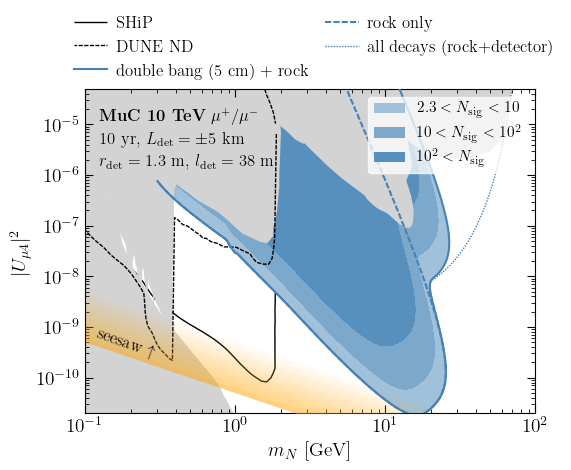

In [14]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

if HAS_HNLIMITS:
    fig, ax = plot_tools.std_plot_limits(
        case_muon, color_fill=False, color_contour=False, annotate=False,
        force_label_color='black', linewidth=0.5, **kwargs
    )
    lighten_color = plot_tools.lighten_color

    SHiP_color = 'black'
    x, y = np.genfromtxt('../../Heavy-Neutrino-Limits/src/HNLimits/include/data/SHiP/Umu4_ESPP25.dat', unpack=True)
    x, y = plot_tools.get_ordered_closed_region([x, y], logx=False, logy=True)
    ax.fill(x, y, facecolor='None', edgecolor=SHiP_color, ls=(1, (1, 0)), lw=1, zorder=-1)
    ax.plot([], [], color=SHiP_color, ls=(1, (1, 0)), lw=1.0, label='SHiP', zorder=1)

    DUNE_color = 'black'
    x, y = np.genfromtxt('../../Heavy-Neutrino-Limits/src/HNLimits/include/data/DUNE_Berryman/DUNE_NuMu_top.dat', unpack=True)
    ax.plot(x, y, color=DUNE_color, ls=(1, (3, 1)), lw=1.0, zorder=3)
    x, y = np.genfromtxt('../../Heavy-Neutrino-Limits/src/HNLimits/include/data/DUNE_Berryman/DUNE_NuMu.dat', unpack=True)
    ax.plot(x, y, color=DUNE_color, ls=(1, (3, 1)), lw=1.0, label='DUNE ND', zorder=3)

else:
    fig, ax = plt.subplots(figsize=(6.5, 5))
    ax.set_xlim(*kwargs['xrange'])
    ax.set_ylim(*kwargs['yrange'])
    lighten_color = lambda color, amount: color

for D in distances:
    colors = [lighten_color('steelblue', x) for x in [0.5, 0.7, 0.9]]

    ax.contourf(
        mN_2D, U2_2D, scan_results[D]['N_only'] + scan_results[D]['N_rock'],
        levels=[2.3, 10, 1e2, np.inf], colors=colors, linewidths=0.0, zorder=0, alpha=1.0
    )
    ax.contour(
        mN_2D, U2_2D, scan_results[D]['N_only'] + scan_results[D]['N_rock'],
        levels=[2.3], colors=['steelblue'], linestyles=["-"], linewidths=[1.5], 
        zorder=5
    )
    ax.contour(
        mN_2D, U2_2D, scan_results[D]['N_rock'],
        levels=[2.3], colors=['steelblue'], linestyles=[(0, (3, 1))], linewidths=[1.5], zorder=5
    )
    ax.contour(
        mN_2D, U2_2D, scan_results[D]['N_all'],
        levels=[2.3], colors=['steelblue'], linestyles=[(0, (1, 1))], linewidths=[1.0], zorder=5
    )

ref_D = distances[0]
ref_cols = [lighten_color('steelblue', x) for x in [0.5, 0.7, 0.9]]

region_handles = [
    Patch(facecolor=ref_cols[0], edgecolor='none', alpha=1, label=r'$2.3 < N_{\rm sig} < 10$'),
    Patch(facecolor=ref_cols[1], edgecolor='none', alpha=1, label=r'$10 < N_{\rm sig} < 10^2$'),
    Patch(facecolor=ref_cols[2], edgecolor='none', alpha=1, label=r'$10^2 < N_{\rm sig}$'),
]

line_handles = []
for D in distances:
    c = scan_results[D]['color']
    line_handles += [
        Line2D([0], [0], color='steelblue', lw=1.5, ls='-', label=f'double bang (5 cm) + rock'),
        Line2D([0], [0], color='steelblue', lw=1.5, ls=(0, (3, 1)), label=f'rock only'),
        Line2D([0], [0], color='steelblue', lw=1.0, ls=(0, (1, 1)), label=f'all decays (rock+detector)'),
    ]

# # inverse HNL decay alone (nubar_e e- -> mu- Nbar, upstream detector): dotted
# ax.contour(mN_2D, U2_2D, N_ihd_mu, levels=[2.3], colors=['black'],
#            linestyles=[(0, (1, 1))], linewidths=[1.4], zorder=5)
# line_handles += [Line2D([0], [0], color='black', lw=1.4, ls=(0, (1, 1)),
#                         label=r'$\bar\nu_e e^-\to \mu^-\bar N$ (IHD)')]

h0, l0 = ax.get_legend_handles_labels()

seen = set()
line_handles_u, line_labels_u = [], []
for h, lab in zip(h0 + line_handles, l0 + [h.get_label() for h in line_handles]):
    if lab not in seen and lab != "_nolegend_":
        line_handles_u.append(h)
        line_labels_u.append(lab)
        seen.add(lab)


leg_lines = ax.legend(
    region_handles, [h.get_label() for h in region_handles],
    loc="upper right",
    frameon=True, facecolor='white', framealpha=0.75,
    fontsize=11, ncol=1, edgecolor='white',
)
ax.legend(
    line_handles_u, line_labels_u,
    loc=(-0.04, 1.01),
    frameon=False, facecolor='white', framealpha=0.75,
    fontsize=12, ncol=2,
    handletextpad=0.5, columnspacing=1.0
)
ax.add_artist(leg_lines)


# Seesaw target from m3 = sqrt(Δm^2_31) with m1 = 0 (normal ordering)
dm2_31_eV2 = 2.5e-3
m3_GeV = np.sqrt(dm2_31_eV2) * 1e-9  # eV -> GeV

mN_vals = np.geomspace(0.1, 100, 200)
u2_seesaw = m3_GeV / mN_vals  # |U|^2 ~ m_light / m_N

# central target line
# ax.plot(
#     mN_vals, u2_seesaw,
#     color="orange", lw=1.0, ls="-",
#     zorder=6
# )

# fade over one decade in mixing: from U^2 down to U^2/10
fade_steps = 10
for k in range(fade_steps):
    f0 = 10 ** (-k / fade_steps)
    f1 = 10 ** (-(k + 1) / fade_steps)
    ax.fill_between(
        mN_vals, u2_seesaw / f0, u2_seesaw / f1,
        color="orange", alpha=0.5 * (1 - k / fade_steps),
        linewidth=0, zorder=4
    )

annot_text = (
    fr"\noindent\textbf{{MuC 10 TeV}} $\mu^+/\mu^-$\vspace{{0.15cm}}\\"
    fr"10 yr, $L_{{\rm det}} = \pm{ref_D/1e5:.0f}$ km\vspace{{0.15cm}}\\"
    fr"$r_{{\rm det}} = {DET_R/100:.1f}$ m, $l_{{\rm det}} = {L_fid/100:.0f}$ m"
)

ax.annotate(
    annot_text,
    xy=(0.03, 0.94),
    xycoords="axes fraction",
    fontsize=12,
    color="black",
    ha="left",
    va="top",
    zorder=5,
    multialignment="center",
)
ax.annotate(r"seesaw $\uparrow$", 
            xy=(0.09, 0.16), xycoords="axes fraction", zorder=5,
            fontsize=12, color="black", ha="center", va="bottom", rotation=-20)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$m_N$ [GeV]", fontsize=14)
ax.set_ylabel(r"$|U_{\mu 4}|^2$", fontsize=14)
ax.set_title("")
ax.tick_params(axis="both", which="major", labelsize=14)
ax.set_ylim(2e-11, 5e-5)
fig.savefig("plots/hnl_muon_mixing.pdf", bbox_inches="tight", dpi=300)

# ================= Electron-mixing reach |U_e4|^2 =================
# Production upscatters the nu_e flux (mu+ -> e+ nu_e nu_mu-bar) via |U_e4|^2;
# decay width and reconstructable BR are e-flavored. Same beam sim, exact
# matrix-element reweighting numubar -> nue (validated to ~0.3%).

In [15]:
# cspell:ignore nuflavor beamdump
# Electron mixing |U_e4|^2: production upscatters the nu_e flux
# (mu+ -> e+ nu_e nu_mu-bar) -- same beam sim, exact reweighting numubar -> nue.
sim_e = sim.reweighted_copy(nuflavor="nue")
sim_e.place_muons_on_lattice(lattice=ring, direction="clockwise")

def flux_at_e(D):
    """nu_e energies, annual weights, and per-neutrino chords through a block at z = D [cm]."""
    return det.flux_with_chords(sim_e, exposure=injections_per_year, dist=D)

MIN_DISP = 3.0
PT_MIN = 0.0  # GeV: pT cut for rock-produced HNLs (no visible production vertex)

colors_e = ["firebrick", "steelblue"]  # electron uses firebrick (muon used steelblue)
scan_results_e = {}

for D, c in zip(distances, colors_e):
    E, w, ch = flux_at_e(D)
    # Bin the flux before scanning: the signal is an integral over the
    # spectrum, so 60 quadrature points reproduce the 33k-event sum to 2
    # parts in 1e5 while making this grid ~130x cheaper (3 costly calls
    # per point here, versus 2 in the muon scan above).
    E, w = dt.bin_flux(E, w, n_bins=60)
    geom = hnl.BeamDumpGeometry(Lss_half, D, L_fid, rock=rock, fiducial_produces=False, gap_cm=GAP)

    N_only = np.zeros((m_N_grid.size, U2_grid.size))
    N_rock = np.zeros_like(N_only)
    N_all = np.zeros_like(N_only)

    for i, m in enumerate(m_N_grid):
        p = hnl.DarkNewsMixingPortal(m, materials=[gas, TARGET_MAT, rock], nuflavor="nue")   # electron mixing
        for j, u in enumerate(U2_grid):
            N_only[i, j] = hnl.signal_events_detector(E, w, p, u, det, min_displacement_cm=MIN_DISP)
            N_rock[i, j] = hnl.signal_events_beamdump(E, w, p, u, geom, pT_min=PT_MIN)
            N_all[i, j] = N_rock[i, j] + hnl.signal_events_detector(E, w, p, u, det, min_displacement_cm=0.0)

    scan_results_e[D] = {
        "color": c,
        "N_only": N_only,
        "N_rock": N_rock,
        "N_tot": N_only + N_rock,
        "N_all": N_all,
    }

mN_2D, U2_2D = np.meshgrid(m_N_grid, U2_grid, indexing='ij')

print("Electron event-rate grids ready:", [f"{D/1e5:.0f} km" for D in scan_results_e])


Electron event-rate grids ready: ['5 km']


/Users/mhostert/Repos/Heavy-Neutrino-Limits/src/HNLimits/plot_tools.py:182: RuntimeWarning: All-NaN slice encountered
  if limit.interp_func is not None and np.nanmax(limit.interp_func(x)) > np.nanmin(limit.interp_func(x)):


/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_39990/894068691.py:36: UserWarning: linewidths is ignored by contourf
  ax.contourf(


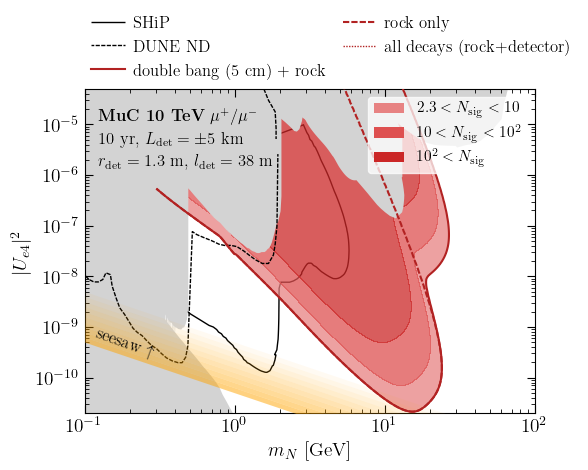

In [16]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

if HAS_HNLIMITS:
    case_e = hnl_tools.Limits(flavor='e', invisible=False, nature='majorana')
    fig, ax = plot_tools.std_plot_limits(
        case_e, color_fill=False, color_contour=False, annotate=False,
        force_label_color='black', linewidth=0.5, **kwargs
    )
    lighten_color = plot_tools.lighten_color

    SHiP_color = 'black'
    xb, yb = np.genfromtxt('../../Heavy-Neutrino-Limits/src/HNLimits/include/data/SHiP/Ue4.dat', unpack=True)
    xt, yt = np.genfromtxt('../../Heavy-Neutrino-Limits/src/HNLimits/include/data/SHiP/Ue4_top.dat', unpack=True)
    x, y = plot_tools.get_ordered_closed_region(
        [np.concatenate([xb, xt]), np.concatenate([yb, yt])], logx=False, logy=True
    )
    ax.fill(x, y, facecolor='None', edgecolor=SHiP_color, ls=(1, (1, 0)), lw=1, zorder=-1)
    ax.plot([], [], color=SHiP_color, ls=(1, (1, 0)), lw=1.0, label='SHiP', zorder=1)

    DUNE_color = 'black'
    x, y = np.genfromtxt('../../Heavy-Neutrino-Limits/src/HNLimits/include/data/DUNE_Berryman/DUNE_NuE_top.dat', unpack=True)
    ax.plot(x, y, color=DUNE_color, ls=(1, (3, 1)), lw=1.0, zorder=3)
    x, y = np.genfromtxt('../../Heavy-Neutrino-Limits/src/HNLimits/include/data/DUNE_Berryman/DUNE_NuE.dat', unpack=True)
    ax.plot(x, y, color=DUNE_color, ls=(1, (3, 1)), lw=1.0, label='DUNE ND', zorder=3)

else:
    fig, ax = plt.subplots(figsize=(6.5, 5))
    ax.set_xlim(*kwargs['xrange'])
    ax.set_ylim(*kwargs['yrange'])
    lighten_color = lambda color, amount: color

for D in distances:
    colors = [lighten_color('firebrick', x) for x in [0.5, 0.7, 0.9]]

    ax.contourf(
        mN_2D, U2_2D, scan_results_e[D]['N_only'] + scan_results_e[D]['N_rock'],
        levels=[2.3, 10, 1e2, np.inf], colors=colors, linewidths=0.0, zorder=0, alpha=0.75
    )
    ax.contour(
        mN_2D, U2_2D, scan_results_e[D]['N_only'] + scan_results_e[D]['N_rock'],
        levels=[2.3], colors=['firebrick'], linestyles=["-"], linewidths=[1.5], zorder=5
    )
    ax.contour(
        mN_2D, U2_2D, scan_results_e[D]['N_rock'],
        levels=[2.3], colors=['firebrick'], linestyles=[(0, (3, 1))], linewidths=[1.5], zorder=5
    )

ref_D = distances[0]
ref_cols = [lighten_color('firebrick', x) for x in [0.5, 0.7, 0.9]]

region_handles = [
    Patch(facecolor=ref_cols[0], edgecolor='none', alpha=1, label=r'$2.3 < N_{\rm sig} < 10$'),
    Patch(facecolor=ref_cols[1], edgecolor='none', alpha=1, label=r'$10 < N_{\rm sig} < 10^2$'),
    Patch(facecolor=ref_cols[2], edgecolor='none', alpha=1, label=r'$10^2 < N_{\rm sig}$'),
]

line_handles = []
for D in distances:
    c = scan_results_e[D]['color']
    line_handles += [
        Line2D([0], [0], color=c, lw=1.5, ls='-', label='double bang (5 cm) + rock'),
        Line2D([0], [0], color=c, lw=1.5, ls=(0, (3, 1)), label='rock only'),
        Line2D([0], [0], color=c, lw=1.0, ls=(0,(1,1)), label='all decays (rock+detector)'),
    ]

h0, l0 = ax.get_legend_handles_labels()

seen = set()
line_handles_u, line_labels_u = [], []
for h, lab in zip(h0 + line_handles, l0 + [h.get_label() for h in line_handles]):
    if lab not in seen and lab != "_nolegend_":
        line_handles_u.append(h)
        line_labels_u.append(lab)
        seen.add(lab)

leg_lines = ax.legend(
    region_handles, [h.get_label() for h in region_handles],
    loc="upper right",
    frameon=True, facecolor='white', framealpha=0.75,
    fontsize=11, ncol=1, edgecolor='white',
)
ax.legend(
    line_handles_u, line_labels_u,
    loc=(0, 1.01),
    frameon=False, facecolor='white', framealpha=0.75,
    fontsize=12, ncol=2,
    handletextpad=0.5, columnspacing=1.0
)
ax.add_artist(leg_lines)

# Seesaw target from m3 = sqrt(Δm^2_31) with m1 = 0 (normal ordering)
dm2_31_eV2 = 2.5e-3
m3_GeV = np.sqrt(dm2_31_eV2) * 1e-9  # eV -> GeV

mN_vals = np.geomspace(0.1, 100, 200)
u2_seesaw = m3_GeV / mN_vals  # |U|^2 ~ m_light / m_N

# fade over one decade in mixing: from U^2 down to U^2/10
fade_steps = 10
for k in range(fade_steps):
    f0 = 10 ** (-k / fade_steps)
    f1 = 10 ** (-(k + 1) / fade_steps)
    ax.fill_between(
        mN_vals, u2_seesaw / f0, u2_seesaw / f1,
        color="orange", alpha=0.5 * (1 - k / fade_steps),
        linewidth=0, zorder=4
    )

annot_text = (
    fr"\noindent\textbf{{MuC 10 TeV}} $\mu^+/\mu^-$\vspace{{0.15cm}}\\"
    fr"10 yr, $L_{{\rm det}} = \pm{ref_D/1e5:.0f}$ km\vspace{{0.15cm}}\\"
    fr"$r_{{\rm det}} = {DET_R/100:.1f}$ m, $l_{{\rm det}} = {L_fid/100:.0f}$ m"
)

ax.annotate(
    annot_text,
    xy=(0.03, 0.94),
    xycoords="axes fraction",
    fontsize=12,
    color="black",
    ha="left",
    va="top",
    zorder=5,
    multialignment="center",
)
ax.annotate(
    r"seesaw $\uparrow$",
    xy=(0.09, 0.16), xycoords="axes fraction", zorder=5,
    fontsize=12, color="black", ha="center", va="bottom", rotation=-20
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$m_N$ [GeV]", fontsize=14)
ax.set_ylabel(r"$|U_{e4}|^2$", fontsize=14)
ax.set_title("")
ax.tick_params(axis="both", which="major", labelsize=14)
ax.set_ylim(2e-11, 5e-5)
fig.savefig("plots/hnl_electron_mixing.pdf", bbox_inches="tight", dpi=300)

## 6. Inverse HNL decay: $\bar\nu_e\, e^- \to \ell^-\, \bar N$ and the $\tau$-mixing reach

The $\bar\nu_e$ flux ($\mu^-$ beam, upstream detector) annihilates on the
electrons of the rock and detector: $\bar\nu_e e^- \to \ell^- \bar N$ with
$\sigma \propto |U_{\ell 4}|^2$ — the massive generalization of inverse
muon/tau decay, recovered exactly as $m_N \to 0$ (validated below). For
$\ell = \tau$ this is the **only channel at this facility sensitive to
$\tau$-coupled HNLs** (upscattering would need a $\nu_\tau$ flux). The
threshold $\sqrt{s} > m_\tau + m_N$ with $\sqrt{s_{\rm max}} = 2.26$ GeV
limits it to $m_N \lesssim 0.48$ GeV, produced only by the multi-TeV Michel
tail. The V–A structure makes the $\bar N$ the soft (backward-CM) leg,
$\langle E_N \rangle \simeq 0.16\, E_\nu$.

Below $m_\tau$ the $\tau$-coupled $N$ has no charged-current decay, so the
mass peak is not reconstructable: visibility here is
${\rm BR}_{\rm vis} = 1 - {\rm BR}(N\to 3\nu) \approx 0.83$ (displaced
vertex + missing energy), a looser criterion than the CC-hadronic mass-peak
one used for the $e/\mu$ panels. IHD uses the upstream detector only
(10 years, one detector).

In [17]:
from mint import xsecs

# validation: m_N -> 0 recovers inverse muon decay and inverse tau decay exactly
Etest = np.array([500., 1000., 3000., 5000.])
for lep, m_l, tag in [("m", const.m_mu, "IMD"), ("t", const.m_tau, "ITD")]:
    ref = xsecs.inverse_lepton_decay_sigma(Etest, "nuebar", lep)
    new = hnl.inverse_hnl_decay_sigma(Etest, 1e-8, m_l)
    with np.errstate(divide="ignore", invalid="ignore"):
        r = np.where(ref > 0, new / ref, np.nan)
    print(f"{tag}: sigma(this work)/sigma(mint) at E = {Etest}: {np.round(r, 5)}"
          "  (nan = below threshold, both zero)")

IMD: sigma(this work)/sigma(mint) at E = [ 500. 1000. 3000. 5000.]: [1. 1. 1. 1.]  (nan = below threshold, both zero)
ITD: sigma(this work)/sigma(mint) at E = [ 500. 1000. 3000. 5000.]: [nan nan nan  1.]  (nan = below threshold, both zero)


In [18]:
# tau-mixing scan: nubar_e e- -> tau- Nbar, rock + in-detector electrons
m_tau_grid = np.geomspace(0.03, 0.47, 32)
U2_tau_grid = np.geomspace(1e-5, 1.0, 60)

N_ihd_tau = np.zeros((m_tau_grid.size, U2_tau_grid.size))
for i, m in enumerate(m_tau_grid):
    for j, u in enumerate(U2_tau_grid):
        N_ihd_tau[i, j] = hnl.signal_events_ihd(
            Ec_ihd, Wc_ihd, m, u, geom_ihd, DET_L, gas, targets,
            flavor="tau", min_displacement_cm=MIN_DISP)   # br_vis = 1 - BR(3nu)

mNt_2D, U2t_2D = np.meshgrid(m_tau_grid, U2_tau_grid, indexing="ij")
imax = np.unravel_index(N_ihd_tau.argmax(), N_ihd_tau.shape)
print(f"tau IHD grid ready; max {N_ihd_tau.max():.1f} events at "
      f"m = {m_tau_grid[imax[0]]:.2f} GeV, U2 = {U2_tau_grid[imax[1]]:.1e}")

tau IHD grid ready; max 1131969.5 events at m = 0.21 GeV, U2 = 1.0e+00


/Users/mhostert/Repos/Heavy-Neutrino-Limits/src/HNLimits/plot_tools.py:182: RuntimeWarning: All-NaN slice encountered
  if limit.interp_func is not None and np.nanmax(limit.interp_func(x)) > np.nanmin(limit.interp_func(x)):


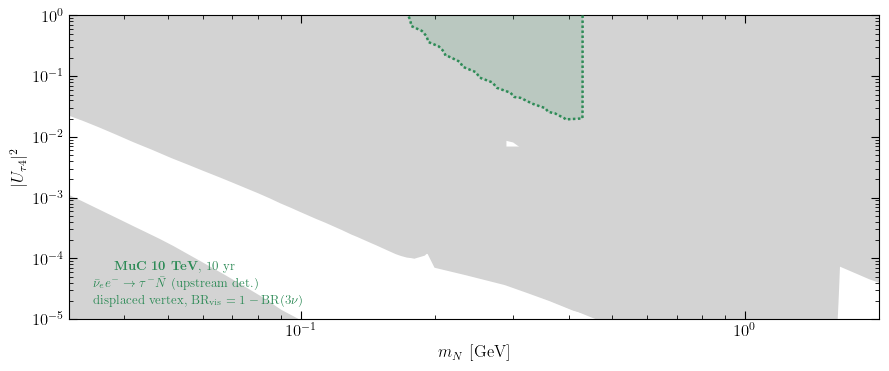

In [19]:
# tau parameter space with existing limits (HNLimits) and the IHD reach (dotted)
if HAS_HNLIMITS:
    case_tau = hnl_tools.Limits(flavor='tau', invisible=False, nature='majorana')
    kwargs_tau = {'xrange': (3e-2, 2.0), 'yrange': (1e-5, 1.0)}
    fig, ax = plot_tools.std_plot_limits(
        case_tau, color_fill=False, color_contour=False, annotate=False,
        force_label_color='black', linewidth=0.5, **kwargs_tau)
else:
    fig, ax = plt.subplots(figsize=(6.5, 5))
    ax.set_xlim(3e-2, 2.0)
    ax.set_ylim(1e-5, 1.0)

ax.contourf(mNt_2D, U2t_2D, N_ihd_tau, levels=[2.3, np.inf],
            colors=['seagreen'], alpha=0.15, zorder=2)
ax.contour(mNt_2D, U2t_2D, N_ihd_tau, levels=[2.3], colors=['seagreen'],
           linestyles=[(0, (1, 1))], linewidths=[1.8], zorder=5)

annot_text = (
    fr"\textbf{{MuC 10 TeV}}, 10 yr\\"
    fr"$\bar\nu_e e^- \to \tau^- \bar N$ (upstream det.)\\"
    fr"displaced vertex, ${{\rm BR}}_{{\rm vis}} = 1 - {{\rm BR}}(3\nu)$"
)
ax.annotate(annot_text, xy=(0.03, 0.04), xycoords="axes fraction", fontsize=9,
            color="seagreen", ha="left", va="bottom", multialignment="left")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$m_N$ [GeV]")
ax.set_ylabel(r"$|U_{\tau 4}|^2$")
ax.set_title("")
fig.savefig("plots/hnl_tau_muc_10tev_ihd.pdf", bbox_inches="tight", dpi=300)

## 7. Decay times of heavy HNLs

A massive HNL travels at $\beta<1$, so its decay vertex is reached
$\Delta t = (1/\beta - 1)\,L_N/c \simeq (m_N^2/2E_N^2)\,L_N/c$ later than a
massless particle covering the same path.

**What the reference is.** The black histogram is the *computed* arrival-time
distribution of the SM neutrino interactions themselves, taken from the beam
simulation ($t=0$ is the bunch centroid crossing the IP; the plotted quantity is
$t - D/c$). Its width is not a detector resolution: it is the **bunch length**,
$\sigma_z = 1.5$ mm $\to \sigma_t \simeq 5$ ps. Every HNL event inherits that
same spread from its parent neutrino and is then shifted by its own kinematic
lag, so each coloured curve is literally the black one convolved with a lag
distribution. All curves are **normalized to unit area** on a **linear** time
axis, so the comparison is purely about where each sits.

**The ordering is not monotonic in mass.** Each mass is evaluated at the
$|U_{\mu4}|^2$ on its exclusion contour, and that coupling varies by two orders
of magnitude across the range. The lag grows like $m_N^2$ at fixed flight path,
but the flight path itself is set by the decay length $\lambda \propto
1/(|U|^2 m_N^5)$: a 30 GeV $N$ sits at $|U_{\mu4}|^2 \sim 3\times10^{-9}$, is
short-lived, and only survives to the fiducial volume if it was produced within
metres of it — so it arrives *prompt*, indistinguishable from the neutrinos.
The light, weakly-coupled end is where the delay is large, because those HNLs
are long-lived enough to be produced kilometres upstream in the rock. Timing is
therefore a handle on the **long-lived** corner of the parameter space, not on
mass as such.


In [20]:
import hnl_widths as hw_t
from mint import xsecs as _xs

rng_h = np.random.default_rng(9)
C_NS = const.c_LIGHT * 1e-9                 # cm per ns
E_f, w_f = E_nu, w_nu                       # flux through the gas (exposure-weighted)
N_EV = 400_000
D0 = 5e5
L_rock0 = D0 - GAP - Lss_half


def _wquantile(x, w, q):
    """Weighted quantile."""
    o = np.argsort(x)
    c = np.cumsum(w[o])
    return np.interp(q, c / c[-1], x[o])


# ---------------------------------------------------------------------------
# (a) The PROMPT REFERENCE: the SM neutrinos themselves.
#     t = 0 is the bunch centroid crossing the IP, and the plotted quantity is
#     Delta t = t_arrival - D0/c, the delay relative to a light signal leaving
#     the IP at that instant. Along the straight the muon moves at v ~ c toward
#     the detector, so the decay position cancels to O(1 - v/c) ~ 2e-10 and the
#     residual width is set by the BUNCH LENGTH (sigma_z = 1.5 mm -> 5 ps).
#     This replaces the old figure's hand-drawn "SM flash" line, which was just
#     placed at the clipping boundary of the log axis.
# ---------------------------------------------------------------------------
(ox, oy, oz), (vx, vy, vz) = dt.sim_rays(sim)
E_s = np.asarray(sim.pnu["E"])
w_s = sim.weights.flatten() * injections_per_year
with np.errstate(divide="ignore", invalid="ignore"):
    t_face = (D0 - oz) / vz
rx, ry = ox + t_face * vx, oy + t_face * vy
m_face = (t_face > 0) & (rx**2 + ry**2 < DET_R**2) & (E_s > 15.0)

pos = np.column_stack([np.asarray(sim.pos["x"]), np.asarray(sim.pos["y"]),
                       np.asarray(sim.pos["z"])])
dist_face = np.linalg.norm(pos[m_face] - np.array([0.0, 0.0, D0]), axis=1)
d_prompt = (np.asarray(sim.mutimes_to_bunchx)[m_face] * 1e9
            + dist_face / C_NS - D0 / C_NS)
# weight by the interaction probability, so this is the SM event sample the
# search actually sees (the timing shape is dominated by the bunch length)
w_prompt = w_s[m_face] * _xs.sigma_CC(E_s[m_face], nuflavor)
p_prompt = w_prompt / w_prompt.sum()
mu_p = np.average(d_prompt, weights=w_prompt)
rms_p = np.sqrt(np.average((d_prompt - mu_p) ** 2, weights=w_prompt))
print(f"prompt nu reference: mean = {mu_p*1e3:+.2f} ps, rms = {rms_p*1e3:.2f} ps")

# ---------------------------------------------------------------------------
# (b) HNL decay-vertex times. The observable delay of an HNL event is
#         Delta t = [parent nu arrival delay] + (1/beta - 1) L_flight / c,
#     i.e. the SAME prompt distribution as above, shifted by the kinematic lag
#     of the massive N over its flight path. Sampling the parent delay from (a)
#     therefore builds in the beam timing spread instead of assuming a delta.
# ---------------------------------------------------------------------------
colors_h = {2.0: "#0072B2", 5.0: "#009E73", 10.0: "#D55E00", 20.0: "#CC79A7"}
samples = []
for m_h in (2.0, 5.0, 10.0, 20.0):
    i_m = int(np.argmin(np.abs(m_N_grid - m_h)))
    Ns = scan_results[D0]["N_tot"][i_m]
    above = Ns >= 2.3
    if not above.any():
        continue
    U2h = U2_grid[int(np.argmax(above))]    # LOWER branch of the contour:
    # the long-lived regime, where km-scale flight paths give measurable delays

    # parent-neutrino energies, weighted by the SAME DarkNews NC-DIS cross
    # section used in the scan (the legacy |U|^2 sigma_NC estimate used here
    # before overestimates production by x2.4-13 at these masses, and the
    # delay goes like 1/E_N^2, so the E_N spectrum matters directly)
    p_h = hnl.DarkNewsMixingPortal(m_h, materials=[gas, TARGET_MAT, rock],
                                   nuflavor=nuflavor)
    sig_h = np.clip(p_h.production_xsec(E_f, U2h, rock), 0.0, None)
    pw = w_f * sig_h
    if pw.sum() <= 0:
        continue
    idx = rng_h.choice(E_f.size, size=N_EV, p=pw / pw.sum())
    E_ev = E_f[idx]

    # inelasticity y ~ 1 + (1-y)^2, by proper rejection sampling. (The old
    # version reassigned REJECTED proposals to y/2 instead of resampling,
    # which biased E_N = (1-y) E_nu high.)
    y_ev = np.empty(N_EV)
    todo = np.ones(N_EV, bool)
    while todo.any():
        n_t = int(todo.sum())
        yy = rng_h.uniform(0.0, 1.0, n_t)
        acc = rng_h.uniform(0.0, 2.0, n_t) < 1.0 + (1.0 - yy) ** 2
        j = np.flatnonzero(todo)[acc]
        y_ev[j] = yy[acc]
        todo[j] = False

    E_N = (1.0 - y_ev) * E_ev
    alive = E_N > 1.001 * m_h
    gam = np.where(alive, E_N / np.maximum(m_h, 1e-9), 1.0)
    beta = np.sqrt(np.clip(1.0 - 1.0 / gam**2, 0.0, 1.0))
    lam = np.maximum(gam * beta * const.invGeV_to_cm / hnl.mixing_total_width(
        m_h, U2h, flavor="mu"), 1e-30)

    # production point: in-detector (uniform) or rock, with the rock distance
    # to the face sampled log-uniformly (importance sampling across lifetimes)
    w_rock, w_det = rock.N * L_rock0, det.nucleon_column()
    in_rock = rng_h.uniform(0, 1, N_EV) < w_rock / (w_rock + w_det)
    u_lo, u_hi = 1.0, L_rock0               # cm upstream of the gap entrance
    u_dist = np.exp(rng_h.uniform(np.log(u_lo), np.log(u_hi), N_EV))
    w_imp = np.where(in_rock, u_dist * np.log(u_hi / u_lo) / L_rock0, 1.0)
    z_prod = np.where(in_rock, D0 - GAP - u_dist,
                      D0 + rng_h.uniform(0, DET_L, N_EV))
    # decay vertex sampled UNIFORMLY in the fiducial gas, weighted by the
    # exact exponential decay density -> every event is a fiducial decay
    z_dec = D0 + rng_h.uniform(0.0, DET_L, N_EV)
    L_flight = z_dec - z_prod
    ok = alive & (L_flight > 0)
    w_dec = np.where(ok, np.exp(-np.clip(L_flight, 0, None) / lam) * DET_L / lam, 0.0)
    w_ev = w_imp * w_dec
    sel = ok & (in_rock | (L_flight > MIN_DISP))

    # parent arrival time + kinematic lag (NO clipping: the old np.clip at
    # 1.2e-4 ns existed only to keep events on a log axis, and piled every
    # sub-ps event into the first bin)
    t_par = d_prompt[rng_h.choice(d_prompt.size, size=N_EV, p=p_prompt)]
    delay = (1.0 / np.maximum(beta, 1e-12) - 1.0) * L_flight / C_NS + t_par

    samples.append(dict(m=m_h, U2=U2h, delay=delay, w=w_ev, ok=ok, sel=sel,
                        br=hw_t.visible_br(m_h, flavor="mu")))

# ---------------------------------------------------------------------------
# (c) Linear time axis, every distribution normalised to unit area, so the
#     comparison is purely about WHERE each one sits, not how many events.
#     The window is the ~ns range a real timing detector would work in; the
#     delay distributions have very long tails (a 2 GeV N at its reach coupling
#     is long-lived enough to decay hundreds of ns late), and the overflow
#     fraction beyond the window is printed and quoted in the legend.
# ---------------------------------------------------------------------------
T_WIN = 0.5                                  # ns
tb = np.linspace(-0.05, T_WIN, 56)          # ~10 ps bins, cf. the 5 ps beam spread
bw = tb[1] - tb[0]


def _density(x, w, bins, norm):
    """Histogram normalised so the FULL sample (including the part outside the
    window) integrates to one -- the plotted area is the fraction in-window."""
    h, _ = np.histogram(x, bins=bins, weights=w)
    return h / (max(norm, 1e-300) * (bins[1] - bins[0]))


prompt nu reference: mean = -0.04 ps, rms = 4.98 ps


m =   2.0 GeV: U2 = 4.1e-09, median delay =    2020.3 ps  [16-84%:      22.6 -    224524.6 ps]  overflow beyond 0.5 ns:  60.7%  selection eff. = 44.6%
m =   5.0 GeV: U2 = 2.3e-10, median delay =    1269.7 ps  [16-84%:      54.3 -     41160.7 ps]  overflow beyond 0.5 ns:  59.9%  selection eff. = 52.1%


m =  10.0 GeV: U2 = 3.7e-11, median delay =     529.8 ps  [16-84%:      75.3 -      5624.0 ps]  overflow beyond 0.5 ns:  51.1%  selection eff. = 52.8%
m =  20.0 GeV: U2 = 2.5e-11, median delay =      75.7 ps  [16-84%:      21.1 -       258.3 ps]  overflow beyond 0.5 ns:   7.1%  selection eff. = 51.5%


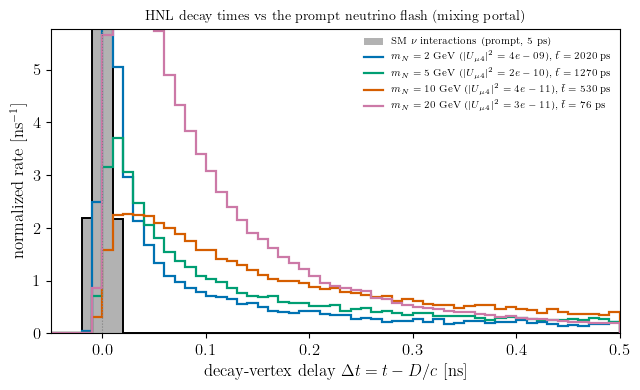

In [21]:


fig, ax = plt.subplots(figsize=(6.5, 4))

# prompt SM neutrinos: the reference everything is measured against
h_nu = _density(d_prompt, w_prompt, tb, w_prompt.sum())
ax.stairs(h_nu, tb, color="black", lw=0, fill=True, alpha=0.30,
          label=r"SM $\nu$ interactions (prompt, 5 ps)")
ax.stairs(h_nu, tb, color="black", lw=1.4)

ymax = h_nu.max()
for s in samples:
    n_all = float(np.sum(s["w"][s["ok"]]))
    h_all = _density(s["delay"][s["ok"]], s["w"][s["ok"]], tb, n_all)
    # the selected subset is NOT drawn: the displacement cut only removes
    # short-flight in-detector events, so its shape is indistinguishable from
    # the solid curve and four extra fills only muddy the figure. Its
    # normalisation (the selection efficiency) is printed instead.
    f_sel = float(np.sum(s["w"][s["sel"]] * s["br"])) / max(n_all, 1e-300)

    over = float(np.sum(s["w"][s["ok"] & (s["delay"] > T_WIN)])) / max(n_all, 1e-300)
    med = _wquantile(s["delay"][s["ok"]], s["w"][s["ok"]], 0.5)
    q16 = _wquantile(s["delay"][s["ok"]], s["w"][s["ok"]], 0.16)
    q84 = _wquantile(s["delay"][s["ok"]], s["w"][s["ok"]], 0.84)

    ax.stairs(h_all, tb, color=colors_h[s["m"]], lw=1.6,
              label=rf"$m_N = {s['m']:.0f}$ GeV "
                    rf"($|U_{{\mu4}}|^2 = {s['U2']:.0e}$), "
                    rf"$\tilde t = {med*1e3:.0f}$ ps")
    ymax = max(ymax, h_all.max())

    print(f"m = {s['m']:5.1f} GeV: U2 = {s['U2']:.1e}, median delay = {med*1e3:9.1f} ps"
          f"  [16-84%: {q16*1e3:9.1f} - {q84*1e3:11.1f} ps]"
          f"  overflow beyond {T_WIN} ns: {over*100:5.1f}%"
          f"  selection eff. = {f_sel*100:4.1f}%")

ax.axvline(0.0, color="gray", ls=":", lw=0.8)
# ax.set_yscale("log")
ax.set_xlim(tb[0], tb[-1])
ax.set_ylim(0, 1.2*ymax/10)
ax.set_xlabel(r"decay-vertex delay $\Delta t = t - D/c$ [ns]")
ax.set_ylabel(r"normalized rate [ns$^{-1}$]")
ax.set_title("HNL decay times vs the prompt neutrino flash (mixing portal)",
             fontsize=10)
ax.legend(frameon=False, fontsize=7, loc="upper right")
plt.tight_layout()
fig.savefig("plots/hnl_decay_times.pdf", bbox_inches="tight", dpi=300)


## 8. Notes

**What this captures.** The correct scaling structure — signal $\propto |U|^4$ in the
long-lived regime turning to $\propto |U|^2$ when the HNL decays promptly — with the
*simulated* forward flux at 5 km, DarkNews-exact upscattering, channel-resolved
partial widths (Bondarenko et al. conventions, validated in Sec. 2), the full
beam-dump geometry (rock production + air gap + fiducial gas volume, upper and lower
reach edges), both mixings ($|U_{\mu 4}|^2$ and $|U_{e4}|^2$), the displaced-vertex
selection (3 cm in-detector displacement; $p_T$ cut for rock production), and the
inverse-HNL-decay channel on the rock electrons.

**Remaining simplifications.**
- **Backgrounds** are assumed zero (2.3 events = 90% CL). Real backgrounds (SM $\nu$
  NC events faking a displaced decay, cosmics, beam-induced) must be estimated; the
  enormous forward flux is both the signal source and the main background.
- **Signal branching** uses the mass-reconstructable no-neutrino CC modes
  (~0.45–0.60 for $\mu$-mixing); detection efficiency inside that class is taken as 1.
- The decay-time figure (Sec. 7) illustrates the in-detector displacement cut only;
  the rock-production $p_T$ cut of the actual contour is not re-applied there.

**Why a muon collider is interesting here.** The forward flux is intense and reaches
multi-TeV, so the HNL boost is huge ($\lambda \propto E_N$) — long decay lengths bring
even weakly-mixed, GeV-scale HNLs into a km-scale detector, a regime complementary to
beam-dump and fixed-target searches.